In [1]:
# Install required libraries (if not already available in the environment)
# seaborn is used for visualization; most others are part of standard Colab setup
!pip install -q seaborn scikit-learn pandas numpy matplotlib joblib


Import modules for data handling, visualization, preprocessing, modeling, tuning, and export.

In [2]:
# ── Standard Library
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ────
import pandas as pd
import numpy as np

# ── Visualization ─────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: Preprocessing ─────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Scikit-learn: Pipeline & ColumnTransformer ───
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ── Scikit-learn: Models ────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: Evaluation Metrics ─────
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# ── Model Persistence ────
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!



Download the dataset directly from a public URL. The IBM Telco Churn dataset is a standard benchmark for binary classification.

In [4]:
from google.colab import files

print("📂 Please upload your Telco Churn CSV file...")
uploaded = files.upload()
if not uploaded:
    raise ValueError("❌ No file uploaded. Please re-run this cell and select a CSV file.")

uploaded_filename = list(uploaded.keys())[0]
print(f"\n✅ File received: '{uploaded_filename}'")
import io
df = pd.read_csv(io.BytesIO(uploaded[uploaded_filename]))

# ──  Confirm successful load ───────────────────────────────────────────
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📋 Columns: {df.columns.tolist()}")
df.head()

📂 Please upload your Telco Churn CSV file...


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv

✅ File received: 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
📐 Shape: 7043 rows × 21 columns
📋 Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Understand the structure, data types, and presence of missing values in the dataset.

In [5]:
# ── Check column names and data types
print("=" * 55)
print("📋 DATASET INFO")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("🔢 MISSING VALUES PER COLUMN")
print("=" * 55)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")

print("\n" + "=" * 55)
print("📊 BASIC STATISTICS (Numeric Columns)")
print("=" * 55)
df.describe()

📋 DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Fix known issues in the Telco dataset — specifically the `TotalCharges` column stored as a string and the `customerID` column which is non-informative.

In [6]:
#  Drop customerID — it's a unique identifier with no predictive value ──
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)
    print("🗑️  Dropped 'customerID' column")

# Convert 'TotalCharges' from object/string to numeric
if df['TotalCharges'].dtype == object:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print(f"🔧 Converted 'TotalCharges' to numeric. NaN count: {df['TotalCharges'].isnull().sum()}")

#Fill NaN values in TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("✅ Filled NaN in 'TotalCharges' with median")

#Encode the target variable 'Churn' to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"\n🎯 Target class distribution:")
print(df['Churn'].value_counts())
print(f"Churn Rate: {df['Churn'].mean():.2%}")

🗑️  Dropped 'customerID' column
🔧 Converted 'TotalCharges' to numeric. NaN count: 11
✅ Filled NaN in 'TotalCharges' with median

🎯 Target class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn Rate: 26.54%



Visualize target distribution, numeric feature distributions, and key categorical patterns.

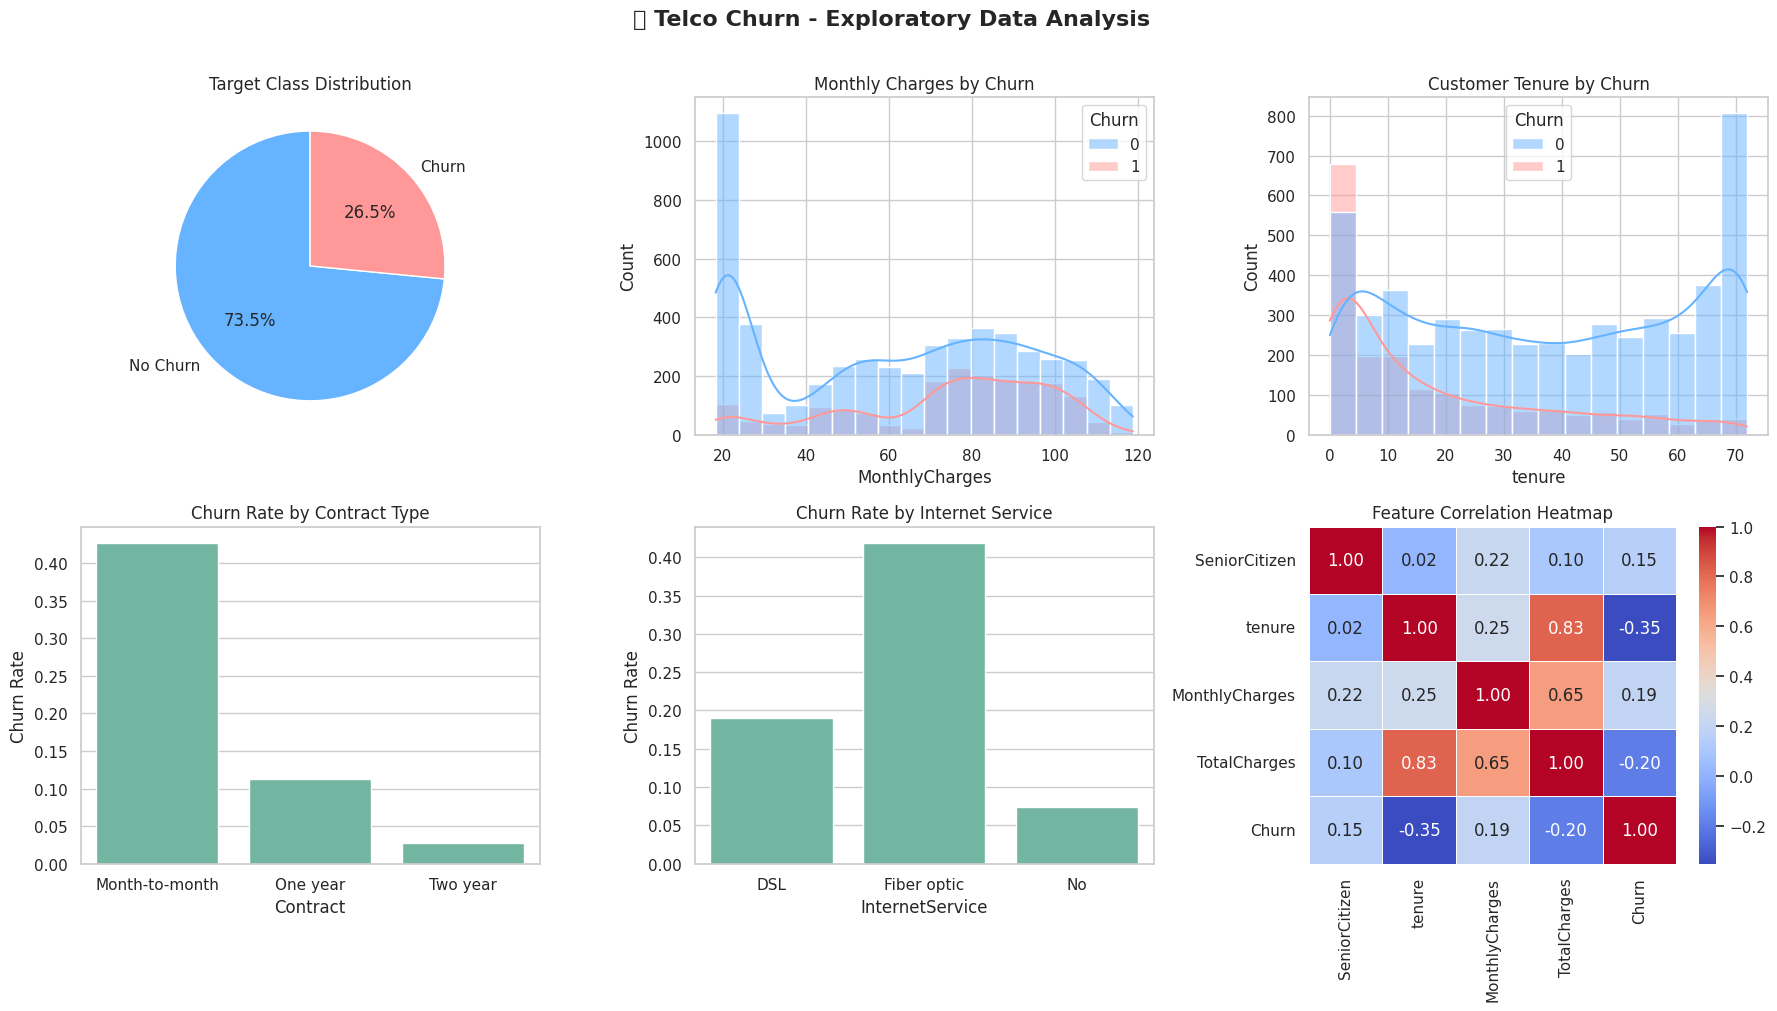

✅ EDA plots saved as 'eda_plots.png'


In [7]:
# ── Set a clean plotting style ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="Set2")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Telco Churn - Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Churn Distribution (Target Balance Check) ─────────────────────────
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
               colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0, 0].set_title('Target Class Distribution')

# ── Plot 2: Monthly Charges Distribution by Churn ─────────────────────────────
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True,
             ax=axes[0, 1], palette={0: '#66b3ff', 1: '#ff9999'})
axes[0, 1].set_title('Monthly Charges by Churn')

# ── Plot 3: Tenure Distribution by Churn ──────────────────────────────────────
sns.histplot(data=df, x='tenure', hue='Churn', kde=True,
             ax=axes[0, 2], palette={0: '#66b3ff', 1: '#ff9999'})
axes[0, 2].set_title('Customer Tenure by Churn')

# ── Plot 4: Contract Type vs Churn ────────────────────────────────────────────
if 'Contract' in df.columns:
    contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
    sns.barplot(data=contract_churn, x='Contract', y='Churn', ax=axes[1, 0])
    axes[1, 0].set_title('Churn Rate by Contract Type')
    axes[1, 0].set_ylabel('Churn Rate')

# ── Plot 5: Internet Service vs Churn ─────────────────────────────────────────
if 'InternetService' in df.columns:
    internet_churn = df.groupby('InternetService')['Churn'].mean().reset_index()
    sns.barplot(data=internet_churn, x='InternetService', y='Churn', ax=axes[1, 1])
    axes[1, 1].set_title('Churn Rate by Internet Service')
    axes[1, 1].set_ylabel('Churn Rate')

# ── Plot 6: Correlation Heatmap (Numeric Features) ────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 2], linewidths=0.5)
axes[1, 2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved as 'eda_plots.png'")


Separate features from the target label and create stratified train/test sets.

In [8]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Feature matrix shape  : {X.shape}")
print(f"Target vector shape   : {y.shape}")

# ── Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\n✅ Train size : {X_train.shape[0]} samples")
print(f"✅ Test size  : {X_test.shape[0]} samples")
print(f"\nTrain churn rate : {y_train.mean():.2%}")
print(f"Test  churn rate : {y_test.mean():.2%}")

Feature matrix shape  : (7043, 19)
Target vector shape   : (7043,)

✅ Train size : 5634 samples
✅ Test size  : 1409 samples

Train churn rate : 26.54%
Test  churn rate : 26.54%



Detect column types automatically so we can apply the correct preprocessing transformers.

In [9]:
# ── Automatically detect column types from the training set ──

# Numeric columns: float or integer dtypes
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns: object dtype (strings)
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"🔢 Numeric Features  ({len(numeric_features)}): {numeric_features}")
print(f"\n🔤 Categorical Features ({len(categorical_features)}): {categorical_features}")

🔢 Numeric Features  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

🔤 Categorical Features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']



Create separate sub-pipelines for numeric and categorical features, then combine them using `ColumnTransformer`.

In [10]:
# ── Numeric Preprocessing Pipeline ───────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ── Categorical Preprocessing Pipeline ───────────────────────────────────────
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── Combine Both Transformers with ColumnTransformer ─────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,     numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("✅ Preprocessing pipeline constructed:")
print("   Numeric  → Median Imputation → Standard Scaling")
print("   Categorical → Mode Imputation → One-Hot Encoding")

✅ Preprocessing pipeline constructed:
   Numeric  → Median Imputation → Standard Scaling
   Categorical → Mode Imputation → One-Hot Encoding



Wrap the preprocessor and each classifier into a single end-to-end `Pipeline` object.

In [11]:
# ── Pipeline 1: Logistic Regression ──────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# ── Pipeline 2: Random Forest ─────────────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("✅ Two full end-to-end pipelines constructed:")
print("   Pipeline 1 → Preprocessor + Logistic Regression")
print("   Pipeline 2 → Preprocessor + Random Forest")

✅ Two full end-to-end pipelines constructed:
   Pipeline 1 → Preprocessor + Logistic Regression
   Pipeline 2 → Preprocessor + Random Forest


Hyperparameter Tuning with GridSearchCV


In [12]:
# ── Cross-Validation Strategy ─────────────────────────────────────────────────
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression Hyperparameter Grid ───────────────────────────────────
lr_param_grid = {
    'classifier__C'       : [0.01, 0.1, 1, 10, 100],
    'classifier__solver'  : ['lbfgs', 'liblinear'],
    'classifier__penalty' : ['l2']
}

# ── Random Forest Hyperparameter Grid ────────────────────────────────────────
rf_param_grid = {
    'classifier__n_estimators'     : [100, 200],
    'classifier__max_depth'        : [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

# ── GridSearchCV for Logistic Regression ─────────────────────────────────────
print("🔍 Running GridSearchCV for Logistic Regression...")
lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
lr_grid_search.fit(X_train, y_train)

print(f"\n✅ Best LR Parameters : {lr_grid_search.best_params_}")
print(f"✅ Best LR CV AUC     : {lr_grid_search.best_score_:.4f}")

🔍 Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Best LR Parameters : {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
✅ Best LR CV AUC     : 0.8462


In [13]:
# ── GridSearchCV for Random Forest
print("🌲 Running GridSearchCV for Random Forest...")
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
rf_grid_search.fit(X_train, y_train)

print(f"\n✅ Best RF Parameters : {rf_grid_search.best_params_}")
print(f"✅ Best RF CV AUC     : {rf_grid_search.best_score_:.4f}")

🌲 Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best RF Parameters : {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
✅ Best RF CV AUC     : 0.8449


Model Evaluation on Test Set
Evaluate both best models on the held-out test set using multiple metrics.

In [14]:
# ── Extract the best estimators found by GridSearchCV ─────────────────────────
best_lr = lr_grid_search.best_estimator_
best_rf = rf_grid_search.best_estimator_

# ── Predict on Test Set ───────────────────────────────────────────────────────
lr_preds      = best_lr.predict(X_test)
lr_proba      = best_lr.predict_proba(X_test)[:, 1]    # Probability of churn

rf_preds      = best_rf.predict(X_test)
rf_proba      = best_rf.predict_proba(X_test)[:, 1]

# ── Compute Metrics ───────────────────────────────────────────────────────────
print("=" * 60)
print("📊 LOGISTIC REGRESSION — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['No Churn', 'Churn']))

print("=" * 60)
print("📊 RANDOM FOREST — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churn']))

📊 LOGISTIC REGRESSION — TEST SET PERFORMANCE
Accuracy : 0.7395
ROC-AUC  : 0.8405

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

📊 RANDOM FOREST — TEST SET PERFORMANCE
Accuracy : 0.7395
ROC-AUC  : 0.8401

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409




Visualize model performance with confusion matrices and ROC curves side by side.

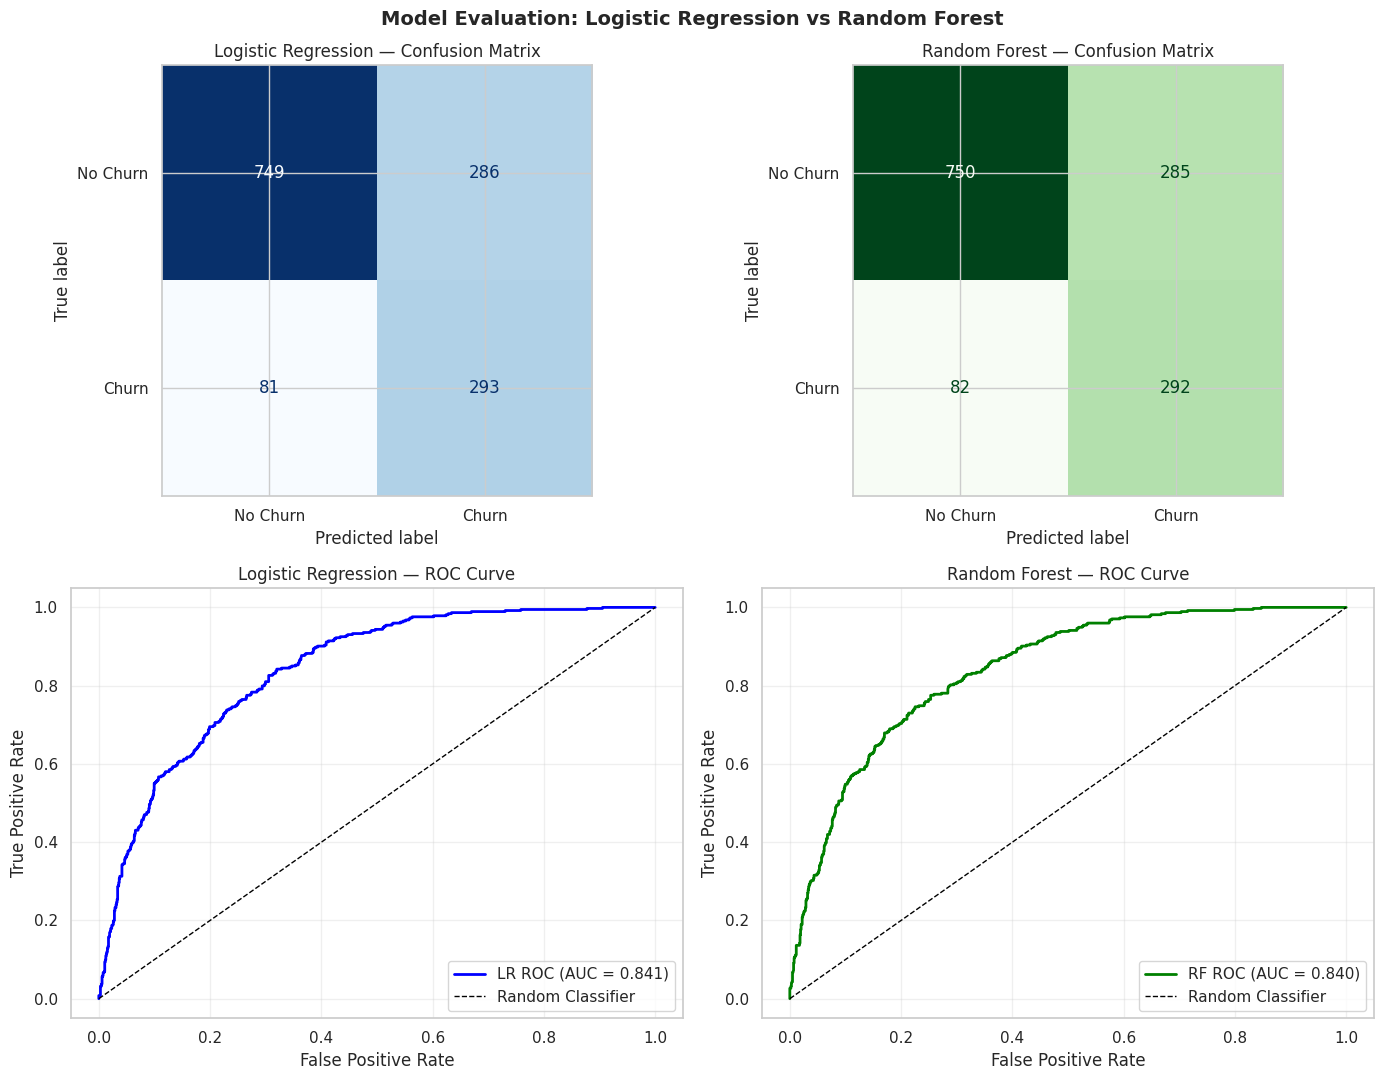

✅ Evaluation plots saved as 'model_evaluation.png'


In [15]:
# ── Create a 2×2 visualization grid ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Model Evaluation: Logistic Regression vs Random Forest',
             fontsize=14, fontweight='bold')

# ── Confusion Matrix: Logistic Regression
cm_lr = confusion_matrix(y_test, lr_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                  display_labels=['No Churn', 'Churn'])
disp_lr.plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Logistic Regression — Confusion Matrix')

# ── Confusion Matrix: Random Forest ──────────────────────────────────────────
cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['No Churn', 'Churn'])
disp_rf.plot(ax=axes[0, 1], colorbar=False, cmap='Greens')
axes[0, 1].set_title('Random Forest — Confusion Matrix')

# ── ROC Curve: Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
auc_lr = roc_auc_score(y_test, lr_proba)
axes[1, 0].plot(fpr_lr, tpr_lr, color='blue', lw=2,
                label=f'LR ROC (AUC = {auc_lr:.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')  # Baseline
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Logistic Regression — ROC Curve')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# ── ROC Curve: Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
auc_rf = roc_auc_score(y_test, rf_proba)
axes[1, 1].plot(fpr_rf, tpr_rf, color='green', lw=2,
                label=f'RF ROC (AUC = {auc_rf:.3f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('Random Forest — ROC Curve')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved as 'model_evaluation.png'")

 Random Forest Feature Importances
Extract and plot the most predictive features from the best Random Forest model.

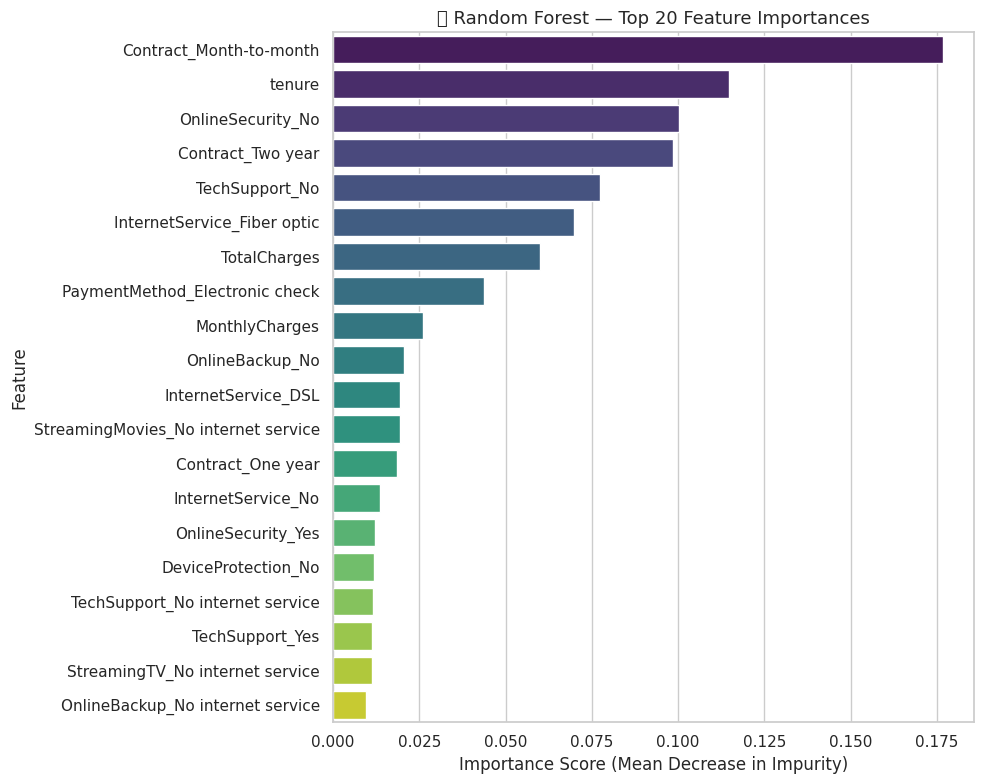


✅ Feature importance chart saved


In [16]:
# ── Get Feature Names After Preprocessing ─────────────────────────────────────

try:
    # Extract the ColumnTransformer from within the pipeline
    preprocessor_fitted = best_rf.named_steps['preprocessor']

    # Get all output feature names after transformation
    feature_names = preprocessor_fitted.get_feature_names_out()
    feature_names_clean = [name.replace('num__', '').replace('cat__', '')
                           for name in feature_names]

    # Extract feature importances from the Random Forest classifier
    importances = best_rf.named_steps['classifier'].feature_importances_

    # Create a DataFrame sorted by importance (descending)
    feat_imp_df = pd.DataFrame({
        'Feature'   : feature_names_clean,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # ── Plot Top 20 Features ──────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=feat_imp_df.head(20),
        y='Feature', x='Importance',
        palette='viridis'
    )
    plt.title('🌿 Random Forest — Top 20 Feature Importances', fontsize=13)
    plt.xlabel('Importance Score (Mean Decrease in Impurity)')
    plt.tight_layout()
    plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Feature importance chart saved")

except Exception as e:
    print(f"⚠️ Could not extract feature names: {e}")
    print("This can happen with older scikit-learn versions. Skipping plot.")

## Select the Best Model
Compare both models on ROC-AUC and select the winner for export.

In [17]:
# ── Side-by-Side Model Comparison Table ──────────────────────────────────────
comparison = pd.DataFrame({
    'Model'             : ['Logistic Regression', 'Random Forest'],
    'CV AUC (train)'    : [lr_grid_search.best_score_, rf_grid_search.best_score_],
    'Test Accuracy'     : [accuracy_score(y_test, lr_preds), accuracy_score(y_test, rf_preds)],
    'Test ROC-AUC'      : [roc_auc_score(y_test, lr_proba), roc_auc_score(y_test, rf_proba)]
})

print("=" * 60)
print("🏆 MODEL COMPARISON SUMMARY")
print("=" * 60)
print(comparison.to_string(index=False))

# ── Pick the Best Model Based on Test ROC-AUC ─────────────────────────────────
best_model_name, best_model = max(
    [('LogisticRegression', best_lr), ('RandomForest', best_rf)],
    key=lambda m: roc_auc_score(y_test, m[1].predict_proba(X_test)[:, 1])
)

print(f"\n🥇 Best Model Selected: {best_model_name}")

🏆 MODEL COMPARISON SUMMARY
              Model  CV AUC (train)  Test Accuracy  Test ROC-AUC
Logistic Regression        0.846206       0.739532      0.840538
      Random Forest        0.844937       0.739532      0.840075

🥇 Best Model Selected: LogisticRegression


## Export Pipelines with `joblib`
Save both trained pipelines to disk. The exported `.pkl` files include the fitted preprocessor and the trained classifier — everything needed for production inference.

In [18]:
# ── Export Both Trained Pipelines ─────────────────────────────────────────────

LR_EXPORT_PATH = 'pipeline_logistic_regression.pkl'
RF_EXPORT_PATH = 'pipeline_random_forest.pkl'
BEST_EXPORT_PATH = f'pipeline_best_{best_model_name}.pkl'

joblib.dump(best_lr,    LR_EXPORT_PATH,   compress=3)
joblib.dump(best_rf,    RF_EXPORT_PATH,   compress=3)
joblib.dump(best_model, BEST_EXPORT_PATH, compress=3)

print("✅ Pipelines exported successfully:")
print(f"   📁 {LR_EXPORT_PATH}")
print(f"   📁 {RF_EXPORT_PATH}")
print(f"   📁 {BEST_EXPORT_PATH}  ← Production Model")

# ── Check file sizes ──────────────────────────────────────────────────────────
import os
for path in [LR_EXPORT_PATH, RF_EXPORT_PATH, BEST_EXPORT_PATH]:
    size_kb = os.path.getsize(path) / 1024
    print(f"   💾 {path}: {size_kb:.1f} KB")

✅ Pipelines exported successfully:
   📁 pipeline_logistic_regression.pkl
   📁 pipeline_random_forest.pkl
   📁 pipeline_best_LogisticRegression.pkl  ← Production Model
   💾 pipeline_logistic_regression.pkl: 2.7 KB
   💾 pipeline_random_forest.pkl: 439.6 KB
   💾 pipeline_best_LogisticRegression.pkl: 2.7 KB


##  Load Pipeline and Run Inference

In [19]:
# ── Step 1: Load the saved pipeline from disk ─────────────────────────────────
loaded_pipeline = joblib.load(BEST_EXPORT_PATH)
print(f"✅ Pipeline loaded successfully from: {BEST_EXPORT_PATH}")
print(f"   Model type: {type(loaded_pipeline.named_steps['classifier']).__name__}")

# ── Step 2: Simulate new unseen data (use a slice of the test set)
new_customers = X_test.iloc[:5].copy()

# ── Step 3: Predict with the loaded pipeline
predictions = loaded_pipeline.predict(new_customers)
probabilities = loaded_pipeline.predict_proba(new_customers)[:, 1]

# ── Step 4: Display results ───────────────────────────────────────────────────
results_df = new_customers.reset_index(drop=True).copy()
results_df['Predicted_Churn'] = predictions
results_df['Churn_Probability'] = probabilities.round(3)
results_df['Actual_Churn'] = y_test.iloc[:5].values

print("\n📋 Prediction Results on New Customers:")
print(results_df[['Predicted_Churn', 'Churn_Probability', 'Actual_Churn']].to_string())

✅ Pipeline loaded successfully from: pipeline_best_LogisticRegression.pkl
   Model type: LogisticRegression

📋 Prediction Results on New Customers:
   Predicted_Churn  Churn_Probability  Actual_Churn
0                0              0.121             0
1                1              0.851             0
2                0              0.127             0
3                1              0.679             0
4                0              0.065             0


##  Download Exported Files
Download the serialized pipeline files to your local machine.

In [20]:

try:
    from google.colab import files

    # Download the best production model pipeline
    files.download(BEST_EXPORT_PATH)
    print(f"✅ Downloaded: {BEST_EXPORT_PATH}")


except ImportError:
    # Running locally (not in Colab) — files are already in the working directory
    print("ℹ️ Not running in Colab. Pipeline files are in the current working directory.")
    print(f"   Look for: {BEST_EXPORT_PATH}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: pipeline_best_LogisticRegression.pkl
